### Loading the dataset
This is the newly feature engineered dataset from `feature_engineering.ipynb`

In [1]:
import pandas as pd
import numpy as np

# loading the dataset into dataframe
df = pd.read_csv('../data/features.csv')

df.head()

,timestamp,server_id,cpu_percent,memory_percent,disk_io,is_anomaly,anomaly_type,cpu_percent_roll_mean_5,cpu_percent_roll_standard_deviation_5,cpu_percent_roll_mean_10,...,hour,day_of_week,cpu_percent_rate_of_change,memory_percent_rate_of_change,disk_io_rate_of_change,server_type_batch_worker,server_type_cache,server_type_database,server_type_load_balancer,server_type_web
0,2025-01-01 00:10:00,web_1,23.238443,36.885905,57.091144,0,normal,20.896125,2.244988,20.896125,...,0,2,3.929764,11.191153,13.110116,0,0,0,0,1
1,2025-01-01 00:15:00,web_1,27.615149,35.100183,51.622232,0,normal,21.676897,2.085378,21.676897,...,0,2,4.376707,-1.785722,-5.468912,0,0,0,0,1
2,2025-01-01 00:20:00,web_1,18.829233,28.184342,33.647097,0,normal,23.161460,3.422705,23.161460,...,0,2,-8.785916,-6.915841,-17.975135,0,0,0,0,1
3,2025-01-01 00:25:00,web_1,18.829315,34.272010,40.813835,0,normal,22.295015,3.541161,22.295015,...,0,2,0.000082,6.087668,7.166738,0,0,0,0,1
4,2025-01-01 00:30:00,web_1,27.896064,31.706079,48.501220,0,normal,21.564164,3.855648,21.717398,...,0,2,9.066749,-2.565931,7.687384,0,0,0,0,1


### Dropping columns 
Dropping the following:
- `timestamp`: raw datetime, not usuable
- `server_id`: just use the lable or identifier

### Training the model using Isolation forest: full 39 feature set

In [2]:
# Splitting the dataframe into testing and training sets
train_df = df[df['timestamp'] < '2025-01-15 00:00:00']
test_df = df[df['timestamp'] >= '2025-01-15 00:00:00']

print(len(train_df))
print(len(test_df))

print(train_df['is_anomaly'].value_counts())
print(test_df['is_anomaly'].value_counts())

60450
30240
is_anomaly
0    60382
1       68
Name: count, dtype: int64
is_anomaly
0    30139
1      101
Name: count, dtype: int64


In [3]:
print(df[['timestamp', 'server_id',
          'cpu_percent',
          'cpu_percent_roll_mean_5',
          'cpu_percent_zscore_5']].head(10))

             timestamp server_id  cpu_percent  cpu_percent_roll_mean_5  \
0  2025-01-01 00:10:00     web_1    23.238443                20.896125   
1  2025-01-01 00:15:00     web_1    27.615149                21.676897   
2  2025-01-01 00:20:00     web_1    18.829233                23.161460   
3  2025-01-01 00:25:00     web_1    18.829315                22.295015   
4  2025-01-01 00:30:00     web_1    27.896064                21.564164   
5  2025-01-01 00:35:00     web_1    23.837174                23.281641   
6  2025-01-01 00:40:00     web_1    17.652628                23.401387   
7  2025-01-01 00:45:00     web_1    22.712800                21.408883   
8  2025-01-01 00:50:00     web_1    17.682912                22.185596   
9  2025-01-01 00:55:00     web_1    17.671351                21.956316   

   cpu_percent_zscore_5  
0              1.043354  
1              2.847566  
2             -1.265732  
3             -0.978690  
4              1.642240  
5              0.124438  
6  

In [21]:
# train set
y_train = train_df['is_anomaly']
# `is_anomaly`: this is the ground truth label, and shoulnd't be used during training
X_train = train_df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X_train.shape)
print(X_train.columns)
print(y_train.value_counts())

(60450, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore_

In [29]:
# test set
y_test = test_df['is_anomaly']
X_test = test_df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X_test.shape)
print(X_test.columns)
print(y_test.value_counts())

(30240, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore_

In [23]:
# calculate the contamination rate 
contamination_rate = y_train.sum() / len(y_train)
print(contamination_rate)

0.0011248966087675765


In [33]:
# fit the model with the dataframe
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination=contamination_rate,random_state=42).fit(X_train)

In [34]:
predictions = clf.predict(X_test)
print(pd.Series(predictions).value_counts())

 1    30207
-1       33
Name: count, dtype: int64


### Classification report 
`Precision` - How many of the true positves flagged by the model is accurate 
$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
`Recall` - How many actually true positives did the model catch 
$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
`F1-score1` - This is the harmonic mean of the recall and precison
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The precison, recall and f1-score (for this first round of training the model) for class `1` is extremley low, meaning the model is not catching anything almost correctly.

In [35]:
# check the models predictions
from sklearn.metrics import classification_report

# if predictions == -1, this would output True
# .astype will convert True to 1
predictions_binary = (predictions == -1).astype(int) # converts -1 to 1

# classification report on the predicitons
classification_report_full_set = classification_report(y_test, predictions_binary)
print(classification_report_full_set)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30139
           1       0.00      0.00      0.00       101

    accuracy                           1.00     30240
   macro avg       0.50      0.50      0.50     30240
weighted avg       0.99      1.00      0.99     30240



#### Confusion matrix

col_0           0   1
is_anomaly           
0           30106  33
1             101   0


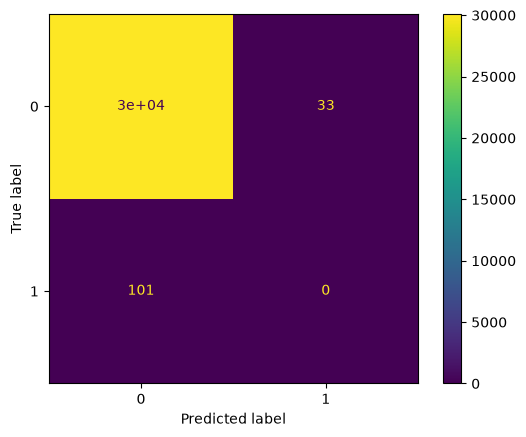

In [38]:
# confusion matrix
print(pd.crosstab(y_test, predictions_binary))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_test,predictions_binary)

display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1'])
display_cm.plot()

plt.show()

### Diagnosing the failure
Using `decision_function` to check whether the true anomalies show up as clearly negative
scores, or whether they blend into the normal range.

What was found:
- There is a measurable difference — anomaly scores are lower on average (`0.147` vs `0.215`)
- The two distributions overlap a lot, meaning individual rows are often not distinguishable
  from one another

This suggests the model is learning something real, but the signal is weak.

In [41]:
test_df['anomaly_score'] = clf.decision_function(X_test)
print(test_df[test_df['is_anomaly'] == 1]['anomaly_score'].describe())
print(test_df[test_df['is_anomaly'] == 0]['anomaly_score'].describe())

count    101.000000
mean       0.152927
std        0.059348
min        0.016129
25%        0.113000
50%        0.150878
75%        0.210839
max        0.230514
Name: anomaly_score, dtype: float64
count    30139.000000
mean         0.208421
std          0.052361
min         -0.041244
25%          0.190966
50%          0.225523
75%          0.245486
max          0.273490
Name: anomaly_score, dtype: float64


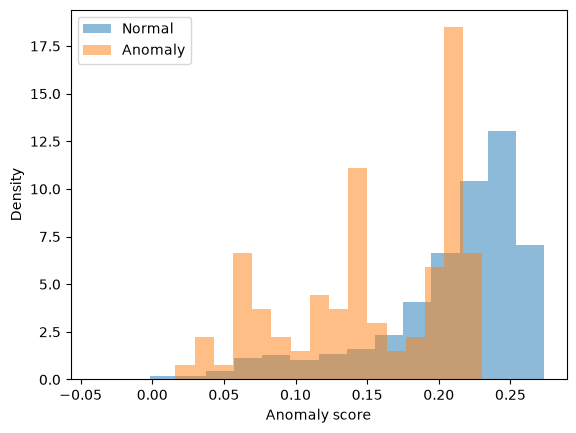

In [56]:
import matplotlib.pyplot as plt

plt.hist(
    test_df[test_df['is_anomaly'] == 0]['anomaly_score'],
    bins=16,
    alpha=0.5,
    density=True,
    label='Normal'
)

plt.hist(
    test_df[test_df['is_anomaly'] == 1]['anomaly_score'],
    bins=16,
    alpha=0.5,
    density=True,
    label='Anomaly'
)

plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.legend()
plt.show()

#### Investigating how extreme the anomalies are
Looking into `web_1` to compare the `anomaly_score`'s for a non-anomaly and anomaly, to see if there is a spike

What was found:
- The anomaly_scores didn't reflect the anomalies clearly, showing no spike or dip
- The anomalies blended into the rest of the data

               timestamp  is_anomaly  anomaly_score
2698 2025-01-10 09:00:00           0       0.123994
2699 2025-01-10 09:05:00           0       0.125036
2700 2025-01-10 09:10:00           0       0.114582
2701 2025-01-10 09:15:00           0       0.127468
2702 2025-01-10 09:20:00           0       0.151003
2703 2025-01-10 09:25:00           0       0.162343
2704 2025-01-10 09:30:00           0       0.171327
2705 2025-01-10 09:35:00           0       0.157526
2706 2025-01-10 09:40:00           0       0.173567
2707 2025-01-10 09:45:00           0       0.164973
2708 2025-01-10 09:50:00           0       0.184259
2709 2025-01-10 09:55:00           0       0.160947
2710 2025-01-10 10:00:00           1       0.131478
2711 2025-01-10 10:05:00           1       0.120454
2712 2025-01-10 10:10:00           1       0.129645
2713 2025-01-10 10:15:00           1       0.107651
2714 2025-01-10 10:20:00           1       0.147962
2715 2025-01-10 10:25:00           1       0.138251
2716 2025-01

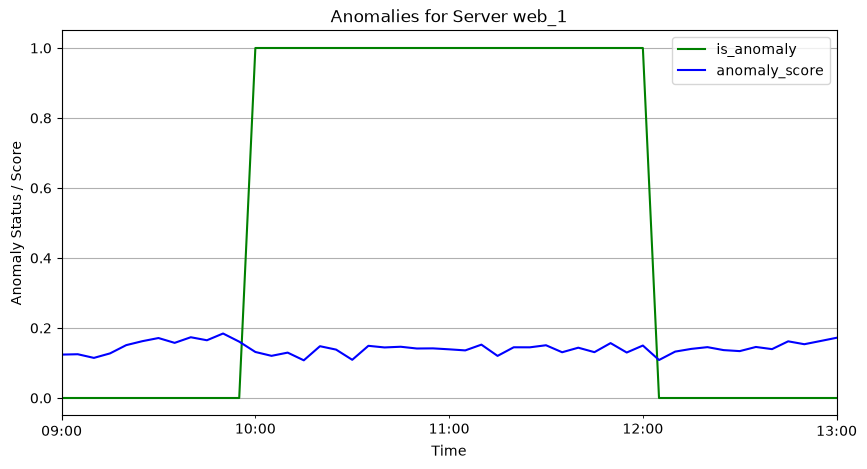

In [10]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

start_time = '2025-01-10 09:00:00'
end_time = '2025-01-10 13:00:00'

condition = (df['server_id'] == 'web_1') & (df['timestamp'].between(start_time, end_time))

plot_data = df[condition][['timestamp','is_anomaly', 'anomaly_score']]
print(plot_data)

plot_data = plot_data.set_index('timestamp') # make timestamp the index of the dataframe

plot_data.plot(figsize=(10, 5), kind='line',color=['green','blue'], title='Anomalies for Server web_1')
plt.ylabel('Anomaly Status / Score')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [11]:
# check the cpu_percent anomalies for web_1 are present
# confirm if that some data is missing
df[(df['server_id'] == 'web_1') & (df['is_anomaly'] == 1)]['cpu_percent'].describe()

count     25.000000
mean      94.096024
std        4.667200
min       83.458590
25%       92.199874
50%       95.118247
75%       97.395977
max      100.000000
Name: cpu_percent, dtype: float64

### Hypothesis 1: The feature set is too large. 
As isolation forest builds trees based on randomly selected features, with so many features and where only a handful of them hold a strong signal of an anomaly, there is a chance that the model is splitting on irrelevant features which don't relate to the particular anomaly.

**Next experiment**: Train the model using a smaller feature set, using more targeted features.

In [12]:
X_small = df[['cpu_percent','cpu_percent_zscore_5','cpu_percent_zscore_10','cpu_percent_zscore_30','server_type_batch_worker','server_type_cache','server_type_database','server_type_load_balancer','server_type_web']]
 
# cpu percent only, contamination rate
cpu_percent_anomalies = df.loc[(df['anomaly_type'] == 'cpu_anomaly') & (df['is_anomaly'] == 1)]
print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_smaller_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_smaller_set}')

# train the model usint the new feature set
clf_smaller_set = IsolationForest(contamination=contamination_rate_smaller_set, random_state=42).fit(X_small)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.0012018965707354726


In [13]:
# Predict using the trained model
predictions_small_set = clf_smaller_set.predict(X_small)
print(pd.Series(predictions_small_set).value_counts())

predictions_binary_small_set = (predictions_small_set == -1).astype(int)

y_cpu_only = (df['anomaly_type'] == 'cpu_anomaly').astype(int)
# classification report on the predicitons
classification_report_small_set = classification_report(y_cpu_only, predictions_binary_small_set)
print(classification_report_small_set)

 1    90583
-1      107
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90581
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90690
   macro avg       0.50      0.50      0.50     90690
weighted avg       1.00      1.00      1.00     90690



From the above experiment, it is clear even modelling on a smaller featrue set doesn't seem to imporove the model. However it has highlighted that the raw data values need to be looked into a little more.

The raw `cpu_percent` values need to be considered, for `batch_worker` server type the cpu_percent is 0 for majority of the day. This means a huge chunk of the whole dataset is sitting around 0. Isolation forest is based on random splits of randomly chosen features, the raw values are incomparable compared to other values within the dataset. Specifcially for `cpu_percent`, `web_1` server raw values can't be comapred to the `batch_worker`'s (constant 0) raw values 

And below we see that the `precision`,`recall` and `f1-score` are still 0.00. This shows that the number of features doesn't affect the models perfomance detecting anomalies.

In [14]:
X_zscore = df[['cpu_percent_zscore_5', 'cpu_percent_zscore_10', 'cpu_percent_zscore_30']]

print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_zscore_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_zscore_set}')

# train the model usint the new feature set
clf_zscore = IsolationForest(contamination=contamination_rate_zscore_set, random_state=42).fit(X_zscore)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.0012018965707354726


In [15]:
# Predict using the trained model
predictions_zscore_set = clf_zscore.predict(X_zscore)
print(pd.Series(predictions_zscore_set).value_counts())

predictions_binary_zscore_set = (predictions_zscore_set == -1).astype(int)

# classification report on the predicitons
classification_report_zscore_set = classification_report(y_cpu_only, predictions_binary_zscore_set)
print(classification_report_zscore_set)

 1    90587
-1      103
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90581
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90690
   macro avg       0.50      0.50      0.50     90690
weighted avg       1.00      1.00      1.00     90690



In [16]:
anomalies = df[df['is_anomaly'] == 1]
pd.set_option('display.max_rows', None)
print(
    anomalies[
        ['server_id', 'anomaly_type', 'anomaly_score']
    ].sort_values('anomaly_score')
)
pd.reset_option('display.max_rows')

             server_id     anomaly_type  anomaly_score
87846   batch_worker_3  disk_io_anomaly      -0.038652
87843   batch_worker_3  disk_io_anomaly      -0.022829
87844   batch_worker_3  disk_io_anomaly       0.000297
87842   batch_worker_3  disk_io_anomaly       0.004155
87845   batch_worker_3  disk_io_anomaly       0.010363
83807   batch_worker_2   memory_anomaly       0.024965
83806   batch_worker_2   memory_anomaly       0.042800
76353   batch_worker_1      cpu_anomaly       0.052327
76339   batch_worker_1      cpu_anomaly       0.054616
83805   batch_worker_2   memory_anomaly       0.055467
29782       database_2      cpu_anomaly       0.056785
29781       database_2      cpu_anomaly       0.057175
76340   batch_worker_1      cpu_anomaly       0.060938
76338   batch_worker_1      cpu_anomaly       0.063226
29794       database_2      cpu_anomaly       0.063403
76341   batch_worker_1      cpu_anomaly       0.065691
29784       database_2      cpu_anomaly       0.066245
76342   ba

### Hypothesis 2: Data heterogeneity across server types

With 5 structurally different server types (15 servers total) sharing a single Isolation
Forest, the model's notion of "normal" is being shaped by all five distributions at once —
in particular, `batch_worker`'s mostly-zero, briefly-spiking pattern appears to dominate the
overall score scale, based on the sorted anomaly-score investigation above. Including
`server_type` as a one-hot feature was an attempt to let the model condition on this
difference, but the experiments above (full feature set, reduced feature set, Z-score-only
feature set) all produced near-identical, near-zero precision/recall for the anomaly class —
suggesting the model isn't reliably learning to separate "normal" per server type from a
single shared training pass.

**Next experiment:** train 5 separate Isolation Forest models, one per `server_type`, each
learning "normal" from only its own server type's data. Evaluate each model against the
anomalies belonging to its own server type, rather than scoring all 15 servers with one
shared model and threshold.

### Server type: Web

In [17]:
# filter down df by server_type_web
filtered_df_web = df[df['server_type_web'] == 1]

y_web = filtered_df_web['is_anomaly']
X_web = filtered_df_web.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

# calculate the contamination rate 
contamination_rate_web = y_web.sum()/len(y_web)
print(f'Contamination rate for web server:{contamination_rate_web}')

Contamination rate for web server:0.0038593009152056456


In [18]:
# train isolation forest model on web server type
clf_web = IsolationForest(contamination=contamination_rate_web, random_state=42).fit(X_web)

In [19]:
predictions_web = clf_web.predict(X_web)
print(pd.Series(predictions_web).value_counts())

predictions_binary_web = (predictions_web == -1).astype(int)
# conatmination rate
classification_report_web = classification_report(y_web, predictions_binary_web)
print(classification_report_web)

 1    18068
-1       70
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18068
           1       0.00      0.00      0.00        70

    accuracy                           0.99     18138
   macro avg       0.50      0.50      0.50     18138
weighted avg       0.99      0.99      0.99     18138

